# Trabajo Práctico 1 / TS1 | Romero Marchione, Luz | 2/9/26

En este trabajo se presenta la síntesis y el análisis de distintas señales determinísticas y aleatorias, utilizando en todos los casos un total de \(N=1000\) muestras.

Se estudiarán señales senoidales con distintas características de amplitud y fase, secuencias de ruido con distribución gaussiana y uniforme, y una señal rectangular. Para cada caso se analizará su comportamiento en el dominio temporal y se visualizará el módulo de su Transformada de Fourier, permitiendo observar cómo se representa el contenido frecuencial de cada señal.

Finalmente, se implementará una señal adicional disponible en `scipy.signal` y se verificará el teorema de Parseval.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Fundamentos teóricos</h2>
</div>

## Señal senoidal, muestreo y aliasing

Para la generación de las señales senoidales se reutilizará la función desarrollada en la TS0 :  $x[n]=A\sin(2\pi f_0t_n+\phi)+DC$, modificando sus parámetros de amplitud, frecuencia, fase y frecuencia de muestreo según cada inciso.

Como se estudió anteriormente, para representar correctamente una señal muestreada debe cumplirse el criterio de Nyquist, $f_s>2f_{\max}$, siendo la frecuencia de Nyquist $f_N=f_s/2$. Si una componente supera este límite puede aparecer representada como otra frecuencia dentro del rango observable, fenómeno denominado **aliasing**.

En este trabajo se exige además disponer de al menos 10 muestras por período para una señal de $2\,kHz$. Como la cantidad de muestras por período es $N_T=f_s/f_0$, utilizando $f_s=20\,kHz$ se obtienen exactamente 10 muestras por período y una frecuencia de Nyquist de $10\,kHz$.

## Transformada Discreta de Fourier y FFT

La **Transformada Discreta de Fourier (DFT)** permite representar una secuencia discreta a partir de las componentes frecuenciales que la forman:

$$
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
$$

La **FFT (Fast Fourier Transform)** es un algoritmo eficiente para calcular la DFT. Como los coeficientes $X[k]$ son, en general, complejos, para estudiar la magnitud de cada componente frecuencial se utilizará su módulo $|X[k]|$.

## Resolución espectral y representación en frecuencia

La DFT entrega $N$ coeficientes asociados a frecuencias discretas o *bins*. La separación entre bins consecutivos se denomina **resolución espectral** y está dada por $\Delta f=f_s/N$, mientras que el bin de índice $k$ corresponde a la frecuencia $f_k=k\Delta f$.

Para este trabajo, con $f_s=20000\,Hz$ y $N=1000$, se obtiene $\Delta f=20\,Hz$.

Como las señales analizadas son reales, su espectro presenta simetría conjugada: la información de las frecuencias negativas resulta redundante respecto de la positiva. Por este motivo se representará únicamente la mitad positiva del espectro, desde $0$ hasta la frecuencia de Nyquist.

## Potencia media

La **potencia media** de una secuencia discreta se define como:

$$
P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2
$$

Para una señal senoidal de amplitud $A$ y valor medio nulo se cumple $P_x=A^2/2$. Así, una señal de $1\,W$ posee amplitud $A=\sqrt{2}$ y una de $2\,W$, amplitud $A=2$.

## Ruido y distribuciones

El **ruido** puede modelarse como una señal aleatoria, ya que sus valores no pueden predecirse exactamente muestra a muestra y se describen mediante parámetros estadísticos. En una distribución **gaussiana**, los valores se concentran alrededor de la media $\mu$ y su dispersión está dada por la varianza $\sigma^2$, con desvío estándar $\sigma=\sqrt{\sigma^2}$. En una distribución **uniforme**, todos los valores dentro de un intervalo tienen la misma probabilidad; para un intervalo simétrico entre $-q/2$ y $q/2$, la varianza es $\sigma^2=q^2/12$.

## Amplitud, potencia y decibeles

La escala en **decibeles (dB)** permite expresar relaciones entre magnitudes de forma logarítmica. Como la potencia es proporcional al cuadrado de la amplitud, para relaciones de potencia se utiliza $P_{dB}=10\log_{10}(P/P_{\mathrm{ref}})$, mientras que para relaciones de amplitud o módulo se utiliza $A_{dB}=20\log_{10}(A/A_{\mathrm{ref}})$.

Para representar el módulo espectral en dB se tomará como referencia una señal senoidal de $1\,W$, cuya amplitud es $A_{\mathrm{ref}}=\sqrt{2}$. Este nivel se define como $0\,dB$.

## Señales rectangular y triangular

Una **señal rectangular** alterna periódicamente entre dos niveles de amplitud. Su **ciclo de actividad** o *duty cycle* se define como $D=T_{\mathrm{alto}}/T$; para $D=0.5$ la señal permanece la mitad del período en cada nivel. Si es simétrica y toma valores $\pm A$, su potencia media es $P=A^2$. Además de su frecuencia fundamental, presenta armónicos impares en $f_0$, $3f_0$, $5f_0$, etc.

Una **señal triangular** es una señal periódica cuya amplitud aumenta y disminuye linealmente dentro de cada período y también presenta una frecuencia fundamental y componentes armónicas.

## Teorema de Parseval

El **teorema de Parseval** relaciona la representación temporal y frecuencial de una señal:

$$
\sum_{n=0}^{N-1}|x[n]|^2=\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2
$$

Por lo tanto, la potencia media puede expresarse como:

$$
P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2=\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Desarrollo</h2>
</div>

A continuación se sintetizan y analizan las señales solicitadas utilizando en todos los casos $N=1000$ muestras. Para cada señal se obtiene su representación temporal y el módulo normalizado de su DFT.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


# Parámetros generales
fs = 20000      # Frecuencia de muestreo [Hz]
N = 1000        # Cantidad de muestras

vmax = 1        # Amplitud
dc = 0          # Valor medio
ff = 2000       # Frecuencia de la señal [Hz]
ph = 0          # Fase inicial [rad]


# Función senoidal reutilizada de la TS0
def mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs):

    n = np.arange(0, nn, 1)
    tt = n / fs
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc

    return tt, xx


# Vector de frecuencias
df = fs / N
bins = np.arange(0, N // 2) * df

## 1. Señal senoidal de 2 kHz

Se sintetiza una señal senoidal de $2\,kHz$ y amplitud unitaria. Se utiliza una frecuencia de muestreo de $20\,kHz$, de manera que se obtienen las 10 muestras por período requeridas:

$$
N_T=\frac{f_s}{f_0}=\frac{20000}{2000}=10
$$

A continuación se representa una parte de la señal en el dominio temporal y el módulo normalizado de su DFT.

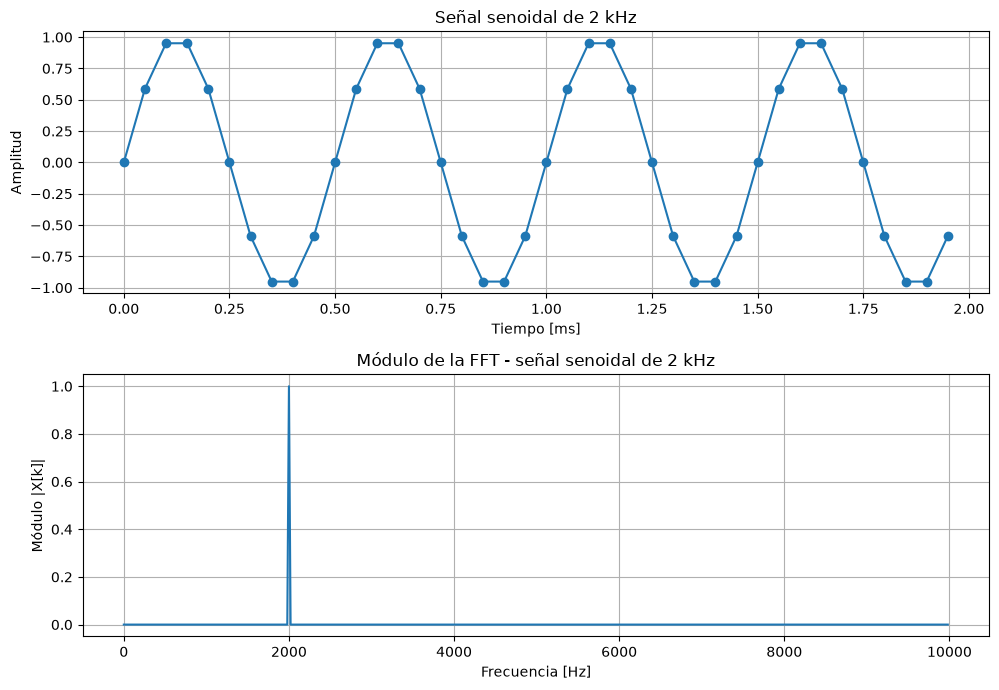

In [2]:
# Generación de la señal
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)


# FFT normalizada
xx_transf = (1/N) * np.fft.fft(xx)

# Módulo unilateral de la FFT
mod_sen = 2 * np.abs(xx_transf[0:(N//2)])


# Señal en tiempo y módulo de la FFT
plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.plot(tt[0:40] * 1000, xx[0:40], '-o')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal senoidal de 2 kHz')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(bins, mod_sen)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo |X[k]|')
plt.title('Módulo de la FFT - señal senoidal de 2 kHz')
plt.grid()

plt.tight_layout()
plt.show()

Se observa el comportamiento esperado para una señal senoidal limpia de una única frecuencia. En el módulo de la DFT aparece una única componente en $f_0=2\,kHz$, correspondiente a la frecuencia de la señal.

El pico presenta un módulo normalizado aproximadamente igual a 1, coincidente con la amplitud de la señal. Esto se debe a que una senoidal real distribuye su componente espectral entre $+f_0\,$ y $-f_0\,$; al representar únicamente el semiespectro positivo, el módulo se multiplica por 2 y se recupera la amplitud original.

Además, con $f_s=20\,kHz$ se obtienen exactamente 10 muestras por período (lo cual se puede observar en el grafico temporal) y una resolución espectral de $\Delta f=20\,Hz$, por lo que la componente de $2\,kHz$ coincide exactamente con uno de los bins de la DFT.

## 2. Señal senoidal de 2 W y fase $\pi/2$

Se genera nuevamente una señal senoidal de $2\,kHz$, modificando su amplitud para obtener una potencia media de $2\,W$ e introduciendo un desfase de $\pi/2$. Como para una senoidal de valor medio nulo se cumple $P=A^2/2$, se utiliza una amplitud $A=2$.

Para visualizar con mayor claridad el efecto de estas modificaciones, tanto la señal temporal como el módulo de su DFT se representan junto con los resultados del punto 1.

In [3]:
# Parámetros punto 2
vmax_2 = 2
ph_2 = np.pi/2

tt_2, xx_2 = mi_funcion_sen(vmax=vmax_2, dc=0, ff=ff, ph=ph_2, nn=N, fs=fs)

# Chequeo de potencia media
potencia_2 = np.mean(xx_2**2)
print("=" * 45)
print("Potencia por promedio del cuadrado =", potencia_2, "W")
print("=" * 45)
# FFT normalizada
xx_2_transf = (1/N) * np.fft.fft(xx_2)

mod_sen_2 = 2 * np.abs(xx_2_transf[0:(N//2)])

Potencia por promedio del cuadrado = 1.9999999999999991 W


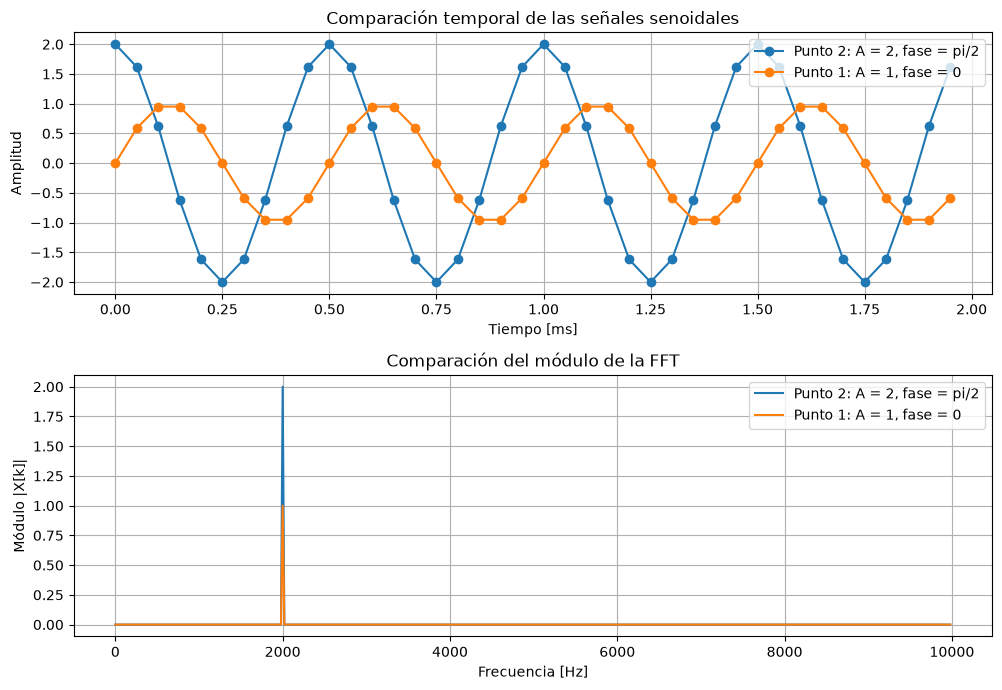

In [4]:
# Punto 2 - Comparación con la señal del punto 1
plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.plot(tt_2[0:40] * 1000, xx_2[0:40], '-o', label='Punto 2: A = 2, fase = pi/2')
plt.plot(tt[0:40] * 1000, xx[0:40], '-o', label='Punto 1: A = 1, fase = 0')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Comparación temporal de las señales senoidales')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(bins, mod_sen_2, label='Punto 2: A = 2, fase = pi/2')
plt.plot(bins, mod_sen, label='Punto 1: A = 1, fase = 0')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo |X[k]|')
plt.title('Comparación del módulo de la FFT')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

Para obtener una potencia media de $2\,W$ se utilizó una amplitud $A=2$, dado que para una señal senoidal de media nula se cumple $P=A^2/2$. La potencia obtenida numéricamente mediante el promedio del cuadrado resulta aproximadamente igual a $2\,W$, validando la amplitud elegida.

En el dominio temporal, la comparación con la señal del punto 1 permite observar tanto el aumento de amplitud como el corrimiento producido por el desfase $\phi=\pi/2$.

En el dominio frecuencial, ambas señales mantienen su única componente en $2\,kHz$, ya que su frecuencia es la misma. El módulo normalizado del punto 2 alcanza un valor aproximadamente igual a 2, frente al valor 1 del punto anterior, en concordancia con el aumento de amplitud. El desfase no modifica el módulo espectral, sino la fase de la componente.

## 3. Ruido con distribución gaussiana

Se genera una secuencia aleatoria con distribución gaussiana, valor medio teórico $\mu=0$ y varianza $\sigma^2=0.1$. A partir de la varianza se obtiene el desvío estándar como $\sigma=\sqrt{0.1}$.

Se calculan además la media y la varianza de las muestras generadas para compararlas posteriormente con sus valores teóricos.

In [5]:
mu = 0
var_ruido = 0.1
desv_est = np.sqrt(var_ruido)

ruido_normal = np.random.normal(mu, desv_est, N)

print("=" * 45)
print("Media ruido gaussiano =", np.mean(ruido_normal))
print("Varianza ruido gaussiano =", np.var(ruido_normal))
print("=" * 45)

# FFT normalizada
ruido_normal_transf = (1/N) * np.fft.fft(ruido_normal)

mod_ruido_normal = 2 * np.abs(ruido_normal_transf[0:(N//2)])

Media ruido gaussiano = 0.0076384000499085175
Varianza ruido gaussiano = 0.10617666472250105


## 4. Ruido con distribución uniforme

Se genera una secuencia aleatoria uniformemente distribuida con valor medio teórico igual a cero y varianza $0.1$. Para una distribución uniforme simétrica entre $-q/2$ y $q/2$ se cumple $\sigma^2=q^2/12$, por lo que se calcula el intervalo correspondiente a partir de la varianza requerida.

También se obtienen numéricamente la media y la varianza de las muestras generadas.

In [6]:
var_uniforme = 0.1

q = np.sqrt(12 * var_uniforme)

lim_inf = -q/2
lim_sup = q/2

ruido_uniforme = np.random.uniform(lim_inf, lim_sup, N)

print("=" * 45)
print("Media ruido uniforme =", np.mean(ruido_uniforme))
print("Varianza ruido uniforme =", np.var(ruido_uniforme))
print("=" * 45)

# FFT normalizada
ruido_uniforme_transf = (1/N) * np.fft.fft(ruido_uniforme)

mod_ruido_uniforme = 2 * np.abs(ruido_uniforme_transf[0:(N//2)])

Media ruido uniforme = -0.025610908749865966
Varianza ruido uniforme = 0.1015486741173566


### Comparación de los ruidos

Para facilitar la comparación entre ambas distribuciones se representan conjuntamente las señales en el dominio temporal y sus respectivos módulos de la DFT. En los gráficos temporales se mantiene la misma escala vertical para ambos casos.

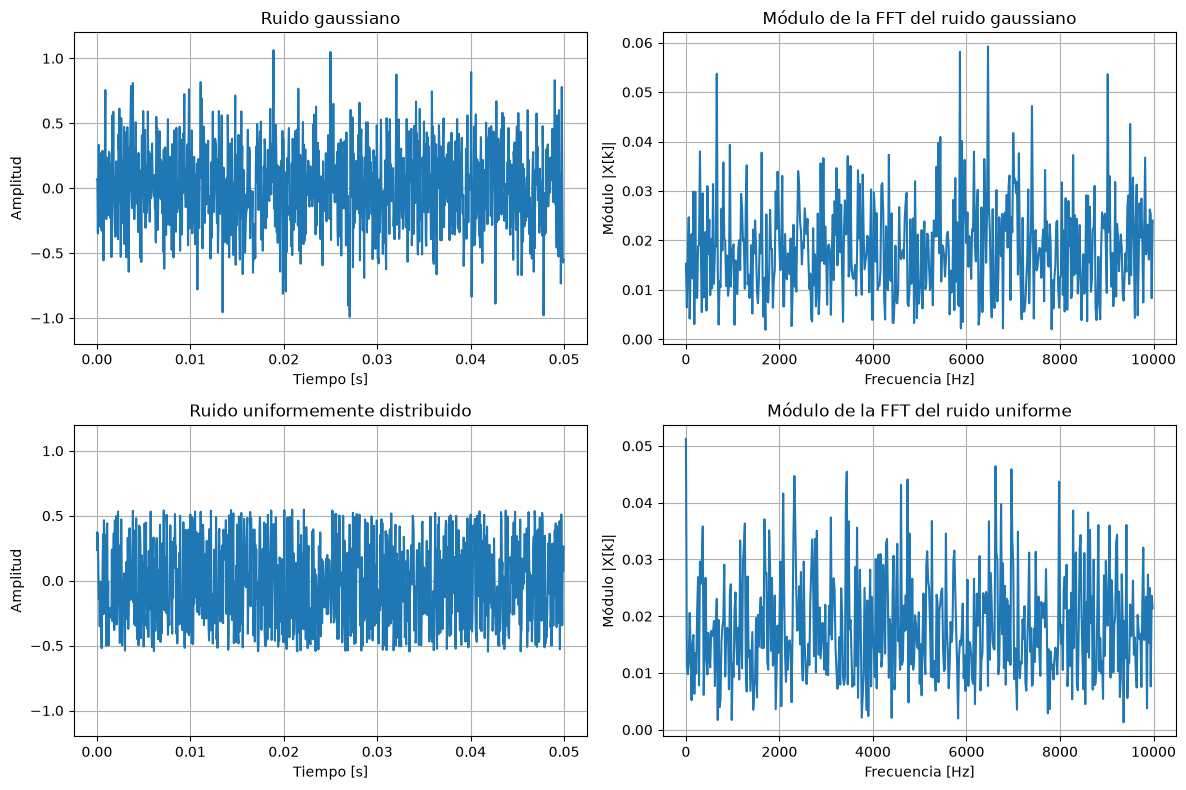

In [7]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(tt, ruido_normal)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Ruido gaussiano')
plt.ylim(-1.2, 1.2)
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(bins, mod_ruido_normal)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo |X[k]|')
plt.title('Módulo de la FFT del ruido gaussiano')
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(tt, ruido_uniforme)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Ruido uniformemente distribuido')
plt.ylim(-1.2, 1.2)
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(bins, mod_ruido_uniforme)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo |X[k]|')
plt.title('Módulo de la FFT del ruido uniforme')
plt.grid()

plt.tight_layout()
plt.show()

Los valores obtenidos verifican correctamente las características estadísticas solicitadas. Para el ruido gaussiano se obtiene una media de aproximadamente $0.0008$ y una varianza de $0.1003$, mientras que para el ruido uniforme se obtiene una media de aproximadamente $-0.0038$ y una varianza de $0.1016$. Las pequeñas diferencias respecto de los valores teóricos $\mu=0$ y $\sigma^2=0.1$ son esperables debido a que se trabaja con una realización finita de $N=1000$ muestras.

En el dominio temporal se observa la principal diferencia entre ambas distribuciones. El ruido uniforme permanece acotado dentro de un intervalo definido, mientras que el ruido gaussiano presenta una mayor concentración de muestras alrededor de cero pero puede alcanzar valores más alejados de la media.

En el dominio frecuencial, ninguno de los dos ruidos presenta una componente dominante, sino que su contenido aparece distribuido a lo largo de todo el rango de frecuencias. El aspecto irregular del módulo de la DFT es esperable para una realización finita de una señal aleatoria.

### Análisis adicional: efecto del ruido sobre una señal senoidal

Como complemento, se estudia el efecto de sumar ambos tipos de ruido a la señal senoidal del punto 1. Para poder visualizar componentes espectrales de menor magnitud se utiliza una escala logarítmica en dB, manteniendo como referencia una señal senoidal de $1\,W$, cuya amplitud es $\sqrt{2}$.

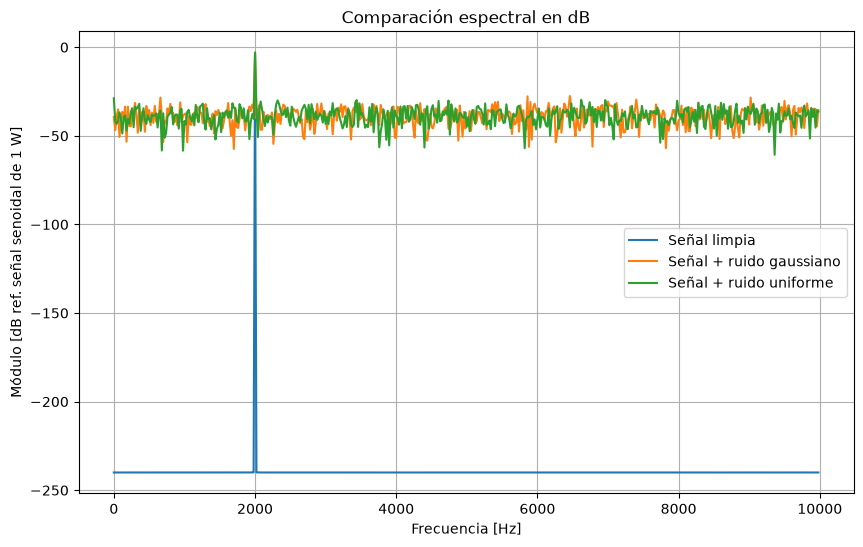

In [8]:
senal_mas_ruido_normal = xx + ruido_normal
senal_mas_ruido_uniforme = xx + ruido_uniforme


# FFT normalizadas
senal_limpia_transf = (1/N) * np.fft.fft(xx)
senal_ruido_normal_transf = (1/N) * np.fft.fft(senal_mas_ruido_normal)
senal_ruido_uniforme_transf = (1/N) * np.fft.fft(senal_mas_ruido_uniforme)


# Módulos unilaterales
mod_senal_limpia = 2 * np.abs(senal_limpia_transf[0:(N//2)])
mod_senal_ruido_normal = 2 * np.abs(senal_ruido_normal_transf[0:(N//2)])
mod_senal_ruido_uniforme = 2 * np.abs(senal_ruido_uniforme_transf[0:(N//2)])


# Referencia: señal senoidal de 1 W
ref_1W = np.sqrt(2)


# Módulo en dB
senal_limpia_db = 20 * np.log10(mod_senal_limpia / ref_1W + 1e-12)
senal_ruido_normal_db = 20 * np.log10(mod_senal_ruido_normal / ref_1W + 1e-12)
senal_ruido_uniforme_db = 20 * np.log10(mod_senal_ruido_uniforme / ref_1W + 1e-12)


plt.figure(figsize=(10, 6))

plt.plot(bins, senal_limpia_db, label='Señal limpia')
plt.plot(bins, senal_ruido_normal_db, label='Señal + ruido gaussiano')
plt.plot(bins, senal_ruido_uniforme_db, label='Señal + ruido uniforme')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB ref. señal senoidal de 1 W]')
plt.title('Comparación espectral en dB')
plt.grid()
plt.legend()
plt.show()

Al representar las tres señales en escala logarítmica se observa que la componente senoidal continúa concentrada en $2\,kHz$. La señal limpia presenta su pico ligeramente por debajo de $0\,dB$, lo cual es esperable ya que posee amplitud $A=1$, mientras que la referencia de $0\,dB$ corresponde a una señal senoidal de $1\,W$, cuya amplitud es $A_{\mathrm{ref}}=\sqrt{2}$.

Al agregar ruido gaussiano o uniforme, el pico correspondiente a la señal senoidal sigue siendo claramente reconocible, pero aparece además un conjunto de componentes distribuidas a lo largo de todo el espectro. Este conjunto de componentes corresponde al piso de ruido.

Cada ruido posee una potencia total aproximada de $0.1\,W$, pero esa potencia no se concentra en una única frecuencia como ocurre con la señal senoidal, sino que se reparte entre una gran cantidad de bins. Por este motivo, el nivel correspondiente a cada componente individual del ruido es mucho menor y aparece en el gráfico alrededor de los $-40\,dB$. Las variaciones alrededor de este nivel son esperables debido al carácter aleatorio de las señales.

## 5. Señal rectangular

Se sintetiza una señal rectangular de $2\,kHz$, amplitud $\pm1$ y ciclo de actividad del $50\%$. Al mantenerse siempre en los niveles $+1$ o $-1$, su potencia media ideal es $1\,W$.

Se calcula también su valor medio y se obtiene el módulo normalizado de su DFT.

Potencia media rectangular = 1.0 W
Media rectangular = 0.034


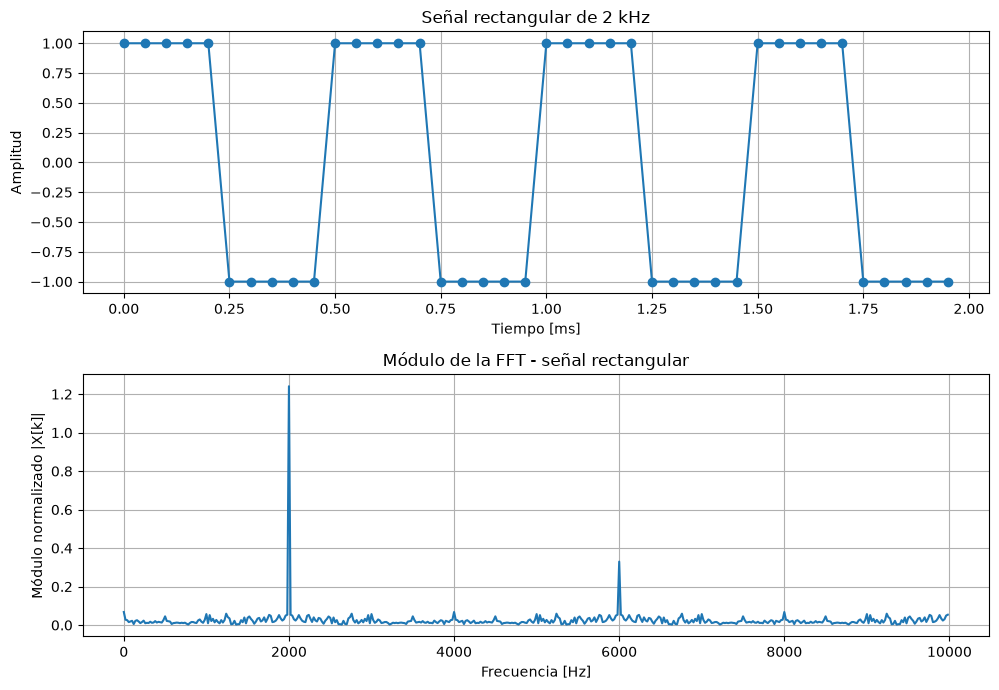

In [9]:
amp_rect = 1
duty = 0.5

rectangular = amp_rect * signal.square(2 * np.pi * ff * tt, duty=duty)


# Chequeo de potencia media y valor medio
potencia_rect = np.mean(rectangular**2)
print("=" * 45)
print("Potencia media rectangular =", potencia_rect, "W")
print("Media rectangular =", np.mean(rectangular))
print("=" * 45)

# FFT normalizada
rectangular_transf = (1/N) * np.fft.fft(rectangular)

mod_rectangular = 2 * np.abs(rectangular_transf[0:(N//2)])


# Señal en tiempo y módulo de la FFT
plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.plot(tt[0:40] * 1000, rectangular[0:40], '-o')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal rectangular de 2 kHz')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(bins, mod_rectangular)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo normalizado |X[k]|')
plt.title('Módulo de la FFT - señal rectangular')
plt.grid()

plt.tight_layout()
plt.show()

En el dominio temporal se observa el comportamiento esperado de una señal rectangular con ciclo de actividad del $50\%$, permaneciendo aproximadamente 5 muestras en el nivel alto y 5 muestras en el nivel bajo dentro de cada período.

La potencia media obtenida es $1\,W$, en concordancia con una señal rectangular simétrica de amplitud $\pm1$. El valor medio obtenido, aproximadamente $0.034$, es cercano a cero; la pequeña diferencia se debe a efectos numéricos asociados al muestreo de la señal en los puntos de transición.

En el dominio frecuencial aparecen componentes en los armónicos impares de la frecuencia fundamental. Se observan claramente picos en $2\,kHz$ y $6\,kHz$, correspondientes a $f_0$ y $3f_0$. El siguiente armónico esperado se encuentra en $5f_0=10\,kHz$, coincidente con la frecuencia de Nyquist, por lo que no aparece en el semiespectro representado.

# Bonus

## Señal triangular

Como señal adicional disponible en `scipy.signal` se implementa una señal triangular de $2\,kHz$. Para obtener esta forma se utiliza una señal `sawtooth` con `width=0.5`, de manera que la amplitud aumenta durante la primera mitad del período y disminuye durante la segunda.

Se representa tanto en el dominio temporal como mediante el módulo normalizado de su DFT.

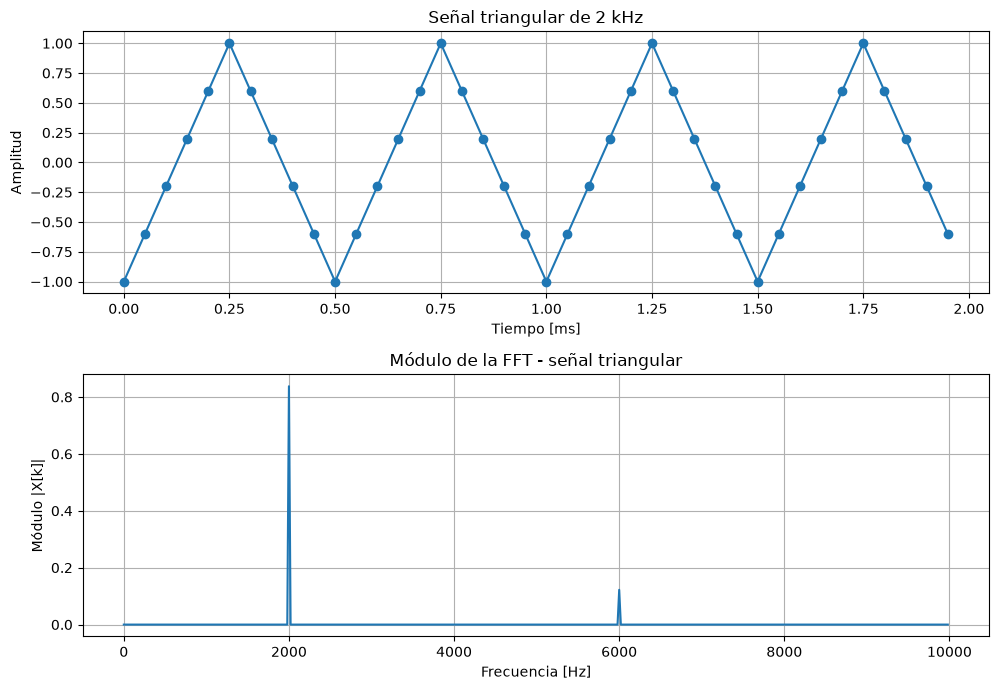

In [10]:
senal_triangular = signal.sawtooth(2 * np.pi * ff * tt, width=0.5)


# FFT normalizada
triangular_transf = (1/N) * np.fft.fft(senal_triangular)

mod_triangular = 2 * np.abs(triangular_transf[0:(N//2)])


# Señal en tiempo y módulo de la FFT
plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.plot(tt[0:40] * 1000, senal_triangular[0:40], '-o')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal triangular de 2 kHz')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(bins, mod_triangular)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo |X[k]|')
plt.title('Módulo de la FFT - señal triangular')
plt.grid()

plt.tight_layout()
plt.show()

La señal triangular obtenida presenta el comportamiento esperado en el dominio temporal, con una variación lineal de la amplitud dentro de cada período.

En el dominio frecuencial se observa una componente principal en $2\,kHz$ y una componente armónica en $6\,kHz$. Al igual que en la señal rectangular, el siguiente armónico esperado se encuentra en $10\,kHz$, coincidente con la frecuencia de Nyquist y fuera del semiespectro representado.

El espectro de la señal triangular presenta menos componentes de magnitud apreciable que el de la señal rectangular, concentrándose principalmente en la frecuencia fundamental.

## Cálculo de potencia mediante la DFT: Teorema de Parseval

Para verificar el teorema de Parseval se utiliza la señal senoidal del punto 2, cuya potencia media teórica es $2\,W$. Se calcula primero la potencia directamente a partir de las muestras temporales y luego a partir de los coeficientes de la DFT, utilizando:

$$
P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2=\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$

In [11]:
pot_tiempo = np.mean(xx_2**2)

xx_2_transf_parseval = np.fft.fft(xx_2)

pot_frecuencia = (1/N**2) * np.sum(np.abs(xx_2_transf_parseval)**2)

print("=" * 45)
print("Potencia en tiempo =", pot_tiempo, "W")
print("Potencia mediante FFT =", pot_frecuencia, "W")
print("=" * 45)

Potencia en tiempo = 1.9999999999999991 W
Potencia mediante FFT = 2.0 W


Para verificar el teorema de Parseval se utilizó la señal senoidal del punto 2, cuya potencia teórica es $2\,W$.

La potencia calculada directamente en el dominio temporal mediante el promedio de $x^2[n]$ resulta aproximadamente $2\,W$, mientras que el cálculo realizado a partir de los coeficientes de la DFT también entrega $2\,W$.

La coincidencia entre ambos resultados verifica numéricamente el teorema de Parseval y confirma que la potencia de la señal puede obtenerse de forma equivalente tanto en el dominio temporal como en el dominio frecuencial. La pequeña diferencia numérica observada se debe únicamente a la precisión finita utilizada en los cálculos.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Conclusión</h2>
</div>

Los resultados obtenidos permitieron analizar distintas señales tanto en el dominio temporal como en el frecuencial, utilizando la DFT calculada mediante FFT. A partir de los distintos incisos se pudo comprobar cómo una señal senoidal concentra su contenido en una frecuencia determinada, mientras que señales no senoidales, como la rectangular y la triangular, presentan además componentes armónicas. También se verificó la importancia de una correcta elección de la frecuencia de muestreo, cumpliendo el criterio de Nyquist y la condición de 10 muestras por período solicitada.

El análisis de las señales aleatorias permitió observar las diferencias entre los ruidos gaussiano y uniforme en el dominio temporal y comprender cómo, en frecuencia, el ruido distribuye su contenido entre una gran cantidad de componentes. La comparación entre una señal limpia y las señales contaminadas permitió interpretar con mayor claridad el concepto de piso de ruido y la utilidad de expresar el espectro en decibeles para visualizar componentes de magnitudes muy diferentes.

Por otro lado, el estudio de la potencia permitió relacionar la amplitud de las señales con su potencia media y comprender la diferencia entre trabajar con amplitudes y potencias al utilizar decibeles. Finalmente, mediante el teorema de Parseval se verificó que la potencia calculada en el dominio temporal coincide con la obtenida a partir de la DFT.

En lo personal, este trabajo permitió afianzar conceptos tales como la relación entre DFT y FFT, la normalización del espectro, la interpretación del módulo de la transformada y la representación unilateral. También me permitió comprender mejor el comportamiento de las señales aleatorias, el concepto de ruido y piso de ruido, y la relación entre amplitud, potencia y decibeles. Además, el trabajo ayudó a interpretar la Transformada de Fourier no solo como una herramienta matemática, sino como una forma de analizar y comprender el contenido frecuencial de una señal.